In [1]:
import torch
import warnings
warnings.filterwarnings("ignore")
import os, sys
import numpy as np
import random as random
from scipy.stats import multivariate_normal

sys.path.insert(0, os.path.abspath(".."))
from Nonparametric.nonparametric import bona_fide_est
from Parametric.utils_model_design import generate_owub_design
from Parametric.Phi import theta_to_Sig_diag
from Parametric.Fn_nested import Fn_inverse_nested
from Parametric.clt_MoM import clt_nested
from Parametric.utils_plot import plot_compare

# Comparison of Covariance Estimators
This notebook reporduces Figure 1.1 in [1].

## Model Setup 
Consider the full-sibling model described in `experiments/fullsib.ipynb`, with $I$ families, $J$ siblings per family, and $p$ traits measured for each individual. The population covariance matrices are specified as
\begin{align*}
\Sigma_1 = \mathrm{diag}(|Z_1|, \ldots, |Z_{80}|, 0, \ldots, 0),
\quad
\Sigma_2 = \mathrm{diag}(|Z_1'|, \ldots, |Z_p'|),
\end{align*}
where ${Z_i}$ and ${Z_i'}$ are independent standard normal variables sorted in descending order. In particular, $\Sigma_1$ has a null space fraction of $0.2$.  

We compare the classical MANOVA and REML estimators with:
- the proposed **parametric method-of-moments** estimators, evaluated
  under two candidate spectral models:
  1. a quadratic decay model, $\,g(x) = \tau\,(1 - \rho x)_{+}^{2}$;
  2. an exponential decay model, $\,g(x) = \tau\exp(-\rho x)$;
- the **nonparametric shrinkage** estimator from our companion work [2].
For the method-of-moments estimators, we additionally display plug-in $95\%$ confidence bands for the estimated spectrum.

[1] Xie R. (2026) Estimating covariance matrices within high-dimensional random effects models (Doctoral dissertation, Stanford University). Available at: https://doi.org/10.25740/nx184bp5557.

[2] Johnstone I. and Xie R. Nonparametric shrinkage estimation of high-dimensional variance component matrices. Manuscript in preparation.

In [2]:
I=100; p=100; J=3
U_list, B_list, _, n = generate_owub_design(I=I,J_list=[J]*I)

seed = 0
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

Z = np.random.randn(int(0.8*p))
Z_prime = np.random.randn(p)

Lambda1_sim = np.concatenate([np.sort(np.abs(Z))[::-1],np.array([0]*(p-int(0.8*p)))])
Lambda2_sim = np.sort(0.5*np.abs(Z_prime))[::-1]

alpha1 = multivariate_normal.rvs(mean=np.zeros(p), cov=np.diag(Lambda1_sim), size=I)
alpha2 = multivariate_normal.rvs(mean=np.zeros(p), cov=np.diag(Lambda2_sim), size=n)

Y = U_list[0]@alpha1 + U_list[1]@alpha2

In [3]:
def compute_Sigma_hat(Y,p,I,J):
    U_list, B_list, _, n = generate_owub_design(I=I,J_list=[J]*I)
    B1, B2 = B_list; 
    ## MANOVA estimate
    L_M = n-J
    Sn1 = 1/p*Y.T@B1@Y; Sn2 = 1/p*Y.T@B2@Y
    Sigma1_M = p/L_M*(Sn1 - (I-1)/(n-I)*Sn2); Sigma2_M = p/(n-I) * Sn2
    Lambda1_M, V1_M = np.linalg.eigh(Sigma1_M.astype(np.float64))
    isort = np.argsort(Lambda1_M)[::-1]
    Lambda1_M = Lambda1_M[isort]
    V1_M = V1_M[:,isort]
    Lambda2_M, V2_M = np.linalg.eigh(Sigma2_M)
    isort = np.argsort(Lambda2_M)[::-1]
    Lambda2_M = Lambda2_M[isort]
    V2_M = V2_M[:,isort]

    ## REML estimate
    mA = p/(I-1)*Sn1; mE = p/I/(J-1)*Sn2
    w, v = np.linalg.eigh(mE); w = np.maximum(w, 0)
    mE_sqrt = v @ np.diag(np.sqrt(w)) @ v.T
    mE_inv_sqrt = v @ np.diag(1 / np.sqrt(w + 1e-15)) @ v.T
    Q = mE_inv_sqrt @ mA @ mE_inv_sqrt
    w, v = np.linalg.eig(Q); w = w - 1; w[w <= 0] = 0
    Sigma1_R = mE_sqrt @ v @ np.diag(w) @ v.T @ mE_sqrt / J
    Lambda1_R, _ = np.linalg.eigh(Sigma1_R)
    Lambda1_R = np.sort(Lambda1_R)[::-1]
    Sigma2_R = 1/(n-1)*((I-1)*(mA-J*Sigma1_R)+I*(J-1)*mE)
    Lambda2_R, _ = np.linalg.eigh(Sigma2_R)
    Lambda2_R = np.sort(Lambda2_R)[::-1]

    ## nonparametric
    B1_MANOVA = (B1/(I-1)-B2/(n-I))/J
    B2_MANOVA = B2/(n-I)
    _, Lambda1_NP, _, _ = bona_fide_est(Y, U_list, B1_MANOVA)
    _, Lambda2_NP, _, _ = bona_fide_est(Y, U_list, B2_MANOVA)

    ## parametric (exp decay)
    decay_list = ['exp', 'exp']
    theta_hat_list_exp = Fn_inverse_nested(Y,B_list,U_list,decay_list,K_list=[2,2],thresh=0.01)
    Lambda1_Exp = theta_to_Sig_diag(theta_hat_list_exp[0],p,decay=decay_list[0])
    Lambda2_Exp = theta_to_Sig_diag(theta_hat_list_exp[1],p,decay=decay_list[1])
    theta_hat_list_exp = [torch.tensor(x) for x in theta_hat_list_exp]

    ## parametric (quad decay)
    decay_list = ['quadratic', 'quadratic']
    theta_hat_list_quad = Fn_inverse_nested(Y,B_list,U_list,decay_list,K_list=[2,2],thresh=0.01)
    Lambda1_Quad = theta_to_Sig_diag(theta_hat_list_quad[0],p,decay=decay_list[0])
    Lambda2_Quad = theta_to_Sig_diag(theta_hat_list_quad[1],p,decay=decay_list[1])
    theta_hat_list_quad = [torch.tensor(x) for x in theta_hat_list_quad]

    Lambda1_est = [Lambda1_M,Lambda1_R,Lambda1_NP,Lambda1_Exp,Lambda1_Quad]
    Lambda2_est = [Lambda2_M,Lambda2_R,Lambda2_NP,Lambda2_Exp,Lambda2_Quad]
    
    return Lambda1_est,Lambda2_est,theta_hat_list_exp,theta_hat_list_quad

### Compute Estimators

In [4]:
Lambda1_est, Lambda2_est, theta_hat_list_exp, theta_hat_list_quad = compute_Sigma_hat(Y,p,I,J)
labels = ['MANOVA','REML', 'Nonparametric', 'MoM(Exponential)','MoM(Quadratic)']
print("Estimators: ",", ".join(x for x in labels))
print("l2-distances from population spectrum: ",", ".join(f"{np.linalg.norm(Lambda1_sim - np.array(arr)):.2f}" for arr in Lambda1_est))
print("REML null space est.:", sum(Lambda1_est[1]<1e-3),"%")
print("MOM (Quadratic) null space est.:", sum(np.array(Lambda1_est[4])<1e-3),"%")

computing a_hat...: 100%|██████████| 100/100 [02:29<00:00,  1.50s/it]


Estimators:  MANOVA, REML, Nonparametric, MoM(Exponential), MoM(Quadratic)
l2-distances from population spectrum:  4.70, 4.75, 2.20, 1.02, 0.87
REML null space est.: 36 %
MOM (Quadratic) null space est.: 16 %


### Plug-in 95\% Confidence intervals for method-of-moments estimators

In [5]:
decay_list = ['exp', 'exp']
bias_theory_exp, cov_theory_exp  = clt_nested(theta_hat_list_exp,B_list,U_list,decay_list,p)

#### Level 2 ####


Evaluating deterministic equivalent LSS...: 100%|██████████| 1000/1000 [00:56<00:00, 17.80it/s]


#### Level 1 ####


Evaluating deterministic equivalent LSS...: 100%|██████████| 1000/1000 [01:56<00:00,  8.59it/s]


In [6]:
decay_list = ['quadratic', 'quadratic']
bias_theory_quad, cov_theory_quad  = clt_nested(theta_hat_list_quad,B_list,U_list,decay_list,p)

#### Level 2 ####


Evaluating deterministic equivalent LSS...: 100%|██████████| 1000/1000 [00:58<00:00, 17.19it/s]


#### Level 1 ####


Evaluating deterministic equivalent LSS...: 100%|██████████| 1000/1000 [01:48<00:00,  9.20it/s]


Confidence interval coverage (exponential):  66.0 %
Confidence interval coverage (quadratic):  81.0 %


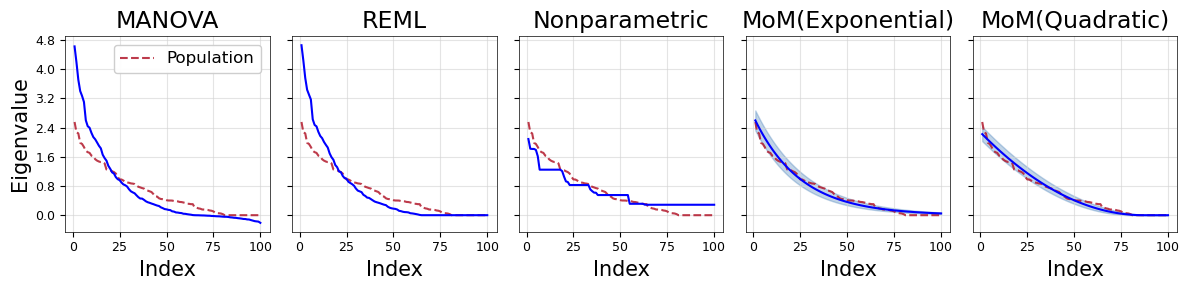

In [8]:
lower_exp = theta_to_Sig_diag(np.array([theta_hat_list_exp[0][0]-2*np.sqrt(cov_theory_exp[0,0]),
                                        theta_hat_list_exp[0][1]+2*np.sqrt(cov_theory_exp[1,1])]),p,decay='exp')
upper_exp = theta_to_Sig_diag(np.array([theta_hat_list_exp[0][0]+2*np.sqrt(cov_theory_exp[0,0]),
                                        theta_hat_list_exp[0][1]-2*np.sqrt(cov_theory_exp[1,1])]),p,decay='exp')

print("Confidence interval coverage (exponential): ", 
      np.mean((Lambda1_sim <= np.array(upper_exp)) & (Lambda1_sim >= np.array(lower_exp)))*100,"%")


lower_quad = theta_to_Sig_diag(np.array([theta_hat_list_quad[0][0]-2*np.sqrt(cov_theory_quad[0,0]),
                                         theta_hat_list_quad[0][1]+2*np.sqrt(cov_theory_quad[1,1])]),p,decay='quadratic')
upper_quad = theta_to_Sig_diag(np.array([theta_hat_list_quad[0][0]+2*np.sqrt(cov_theory_quad[0,0]),
                                         theta_hat_list_quad[0][1]-2*np.sqrt(cov_theory_quad[1,1])]),p,decay='quadratic')

print("Confidence interval coverage (quadratic): ", 
      np.mean((Lambda1_sim <= np.array(upper_quad)) & (Lambda1_sim >= np.array(lower_quad)))*100,"%")

plot_compare(Lambda1_sim,Lambda1_est,labels, save = 'image/thesis_Gaussian_null_Sigma1_compare',
             exp_conf=[lower_exp,upper_exp],quad_conf=[lower_quad,upper_quad])